# Exploring Physician Ownership Payments and Exclusion Status

This notebook provides an **exploratory data analysis (EDA)** of physician ownership payments in the United States from 2021 to 2023, combined with the **OIG Exclusion List** to identify potentially excluded providers.

The main objectives of this analysis are:

1. **Understand the ownership payment dataset**  
   - Examine its structure, missing data, and distribution of key variables such as payment amounts, manufacturers, and states.

2. **Clean and standardize the data**  
   - Ensure proper formatting of NPIs, standardize physician names, and remove excluded providers for accurate analysis.

3. **Identify excluded providers**  
   - Match ownership records with the OIG Exclusion List by NPI and full name.
   - Quantify the number of excluded vs. non-excluded providers.

4. **Analyze payment patterns**  
   - Visualize distributions of payments, top manufacturers, and states.
   - Compare payment values between excluded and non-excluded providers.

5. **Provide actionable insights**  
   - Highlight patterns in excluded providers by state and payment value.
   - Offer a clean, analysis-ready dataset for further research or modeling.

This notebook does data manipulation and visualization, and follows a structured, step-by-step approach to understand the scope and implications of physician ownership payments in the healthcare landscape.

In [1]:
import pandas as pd

### Ownership & Exclusion Data Overview

We begin by loading the ownership payment dataset (2021-2023) and the OIG Exclusion List.  

- **Ownership Dataset:** Contains payments made to physicians from manufacturers and GPOs.  
- **Exclusion Dataset:** Lists providers excluded from federal healthcare programs.  

We inspect the first few rows, shapes, columns, and data types to understand dataset structure and identify any initial inconsistencies.


In [2]:
#The Ownership dataset (2021-2023)
df = pd.read_csv("/dsa/groups/casestudycf25/team02/OWNRSHP_PGYR2021_2023.csv")
df.head(10)

,Change_Type,Physician_Profile_ID,Physician_NPI,Physician_First_Name,Physician_Middle_Name,Physician_Last_Name,Physician_Name_Suffix,Recipient_Primary_Business_Street_Address_Line1,Recipient_Primary_Business_Street_Address_Line2,Recipient_City,...,Value_of_Interest,Terms_of_Interest,Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country,Dispute_Status_for_Publication,Interest_Held_by_Physician_or_an_Immediate_Family_Member,Payment_Publication_Date
0,UNCHANGED,361157,1.962476e+09,Marlene,NaN,Moster,NaN,100 Presidential Bvd,Suite 200,Bala Cynwyd,...,296.69,Equity Distribution payment,"Mobius Therapeutics, LLC",1.000000e+11,"Mobius Therapeutics, LLC",MO,United States,No,Physician Covered Recipient,6/30/2025
1,UNCHANGED,173155,1.821079e+09,Robert,NaN,Ritch,NaN,455 W 57th Street,NaN,New York,...,593.37,Equity Distribution payment,"Mobius Therapeutics, LLC",1.000000e+11,"Mobius Therapeutics, LLC",MO,United States,No,Physician Covered Recipient,6/30/2025
2,NEW,84927,1.881709e+09,andreluiz,NaN,davila,NaN,185 pilgrim road,baker4,Boston,...,31926.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
3,NEW,119199,1.639176e+09,shephal,NaN,doshi,NaN,2001 santa monica blvd,ste280w,santa monica,...,43161.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
4,NEW,233626,1.144259e+09,srinivas,NaN,dukkipati,NaN,1 gustav l. levy place,NaN,new york,...,87984.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
5,NEW,215154,1.760442e+09,james,NaN,mcguckin,jr.,4200 market st.,fl. 2,philadelphia,...,158172.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
6,NEW,257970,1.679557e+09,alexander,NaN,mittnacht,NaN,westchester county medical center,100 woods road,valhalla,...,26822.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
7,NEW,214322,1.720069e+09,ashok,NaN,reddy,NaN,44344 dequindre road,suite 210,sterling heights,...,36656.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
8,NEW,230570,1.083672e+09,vivek,NaN,reddy,NaN,5 E 98th street,3rd floor,New York,...,234469.00,private equity,"Manual Surgical Sciences, LLC",1.000010e+11,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
9,UNCHANGED,773428,1.407046e+09,Aravind,NaN,Swaminathan,MD,751 S Bascom Avenue,NaN,San Jose,...,295760.00,"Common stock, common stock options and preferr...","BioTrace Medical, Inc.",1.000000e+11,"BioTrace Medical, Inc.",CA,United States,No,Physician Covered Recipient,6/30/2025


In [3]:
#Shape and Columns of Ownership Datasets
print(df.shape)
print(df.columns)
df.info()

(12710, 30)
Index(['Change_Type', 'Physician_Profile_ID', 'Physician_NPI',
       'Physician_First_Name', 'Physician_Middle_Name', 'Physician_Last_Name',
       'Physician_Name_Suffix',
       'Recipient_Primary_Business_Street_Address_Line1',
       'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City',
       'Recipient_State', 'Recipient_Zip_Code', 'Recipient_Country',
       'Recipient_Province', 'Recipient_Postal_Code', 'Physician_Primary_Type',
       'Physician_Specialty', 'Record_ID', 'Program_Year',
       'Total_Amount_Invested_USDollars', 'Value_of_Interest',
       'Terms_of_Interest',
       'Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country',
       'Dispute_Status_

In [4]:
#OIG Exclusion List
df2 = pd.read_csv("/dsa/groups/casestudycf25/team02/LEIE_OIG_Exclusion_List.csv", dtype=str)
df2.head(10)

,LASTNAME,FIRSTNAME,MIDNAME,BUSNAME,GENERAL,SPECIALTY,UPIN,NPI,DOB,ADDRESS,CITY,STATE,ZIP,EXCLTYPE,EXCLDATE,REINDATE,WAIVERDATE,WVRSTATE
0,NaN,NaN,NaN,"#1 MARKETING SERVICE, INC",OTHER BUSINESS,SOBER HOME,NaN,0000000000,NaN,239 BRIGHTON BEACH AVENUE,BROOKLYN,NY,11235,1128a1,20200319,00000000,00000000,NaN
1,NaN,NaN,NaN,"1 BEST CARE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,0000000000,NaN,"2161 UNIVERSITY AVENUE W, STE",SAINT PAUL,MN,55114,1128b5,20230518,00000000,00000000,NaN
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,20220320,00000000,00000000,NaN
3,NaN,NaN,NaN,14 LAWRENCE AVE PHARMACY,PHARMACY,NaN,NaN,0000000000,NaN,14 LAWRENCE AVENUE,SMITHTOWN,NY,11787,1128a1,19880830,00000000,00000000,NaN
4,NaN,NaN,NaN,143 MEDICAL EQUIPMENT CO,DME COMPANY,DME - OXYGEN,NaN,0000000000,NaN,701 NW 36 AVENUE,MIAMI,FL,33125,1128b7,19970620,00000000,00000000,NaN
5,NaN,NaN,NaN,"149 BALLSTON AVENUE, LLC",OTHER BUSINESS,MARKETING FIRM,NaN,0000000000,NaN,"C/O 365 W END AVE, APT 5A",NEW YORK,NY,10024,1128b6,20230227,00000000,00000000,NaN
6,NaN,NaN,NaN,184TH STREET PHARMACY CORP,OTHER BUSINESS,PHARMACY,NaN,1922348218,NaN,69 E 184TH ST,BRONX,NY,10468,1128a1,20180419,00000000,00000000,NaN
7,NaN,NaN,NaN,1951 FLATBUSH AVENUE PHARMACY,PHARMACY,NaN,NaN,0000000000,NaN,1951 FLATBUSH AVE,BROOKLYN,NY,11234,1128b5,20090319,00000000,00000000,NaN
8,NaN,NaN,NaN,"1ST COMMUNITY HEALTH CTR, LTD",CLINIC,NaN,NaN,0000000000,NaN,3138 W CERMAK ROAD,CHICAGO,IL,60623,1128a1,19940524,00000000,00000000,NaN
9,NaN,NaN,NaN,1ST REHABILITATION OF PORT ST,MANAGEMENT SVCS CO,NaN,NaN,0000000000,NaN,C/O 3659 MAGUIRE BLVD,ORLANDO,FL,32803,1128b8,20020919,00000000,00000000,NaN


In [5]:
#Shape and Columns of OIG Exclusion List
print(df2.shape)
print(df2.columns)
df2.info()

(81991, 18)
Index(['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY',
       'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE',
       'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81991 entries, 0 to 81990
Data columns (total 18 columns):
LASTNAME      78625 non-null object
FIRSTNAME     78624 non-null object
MIDNAME       57938 non-null object
BUSNAME       3364 non-null object
GENERAL       81991 non-null object
SPECIALTY     77905 non-null object
UPIN          5970 non-null object
NPI           81991 non-null object
DOB           77763 non-null object
ADDRESS       81987 non-null object
CITY          81991 non-null object
STATE         81991 non-null object
ZIP           81991 non-null object
EXCLTYPE      81991 non-null object
EXCLDATE      81991 non-null object
REINDATE      81991 non-null object
WAIVERDATE    81991 non-null object
WVRSTATE      5 non-null object
dty

In [6]:
df.isna().sum().sort_values(ascending=False)

Recipient_Postal_Code                                               12709
Recipient_Province                                                  12709
Physician_Name_Suffix                                               12115
Physician_Middle_Name                                                8428
Recipient_Primary_Business_Street_Address_Line2                      7033
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State        123
Terms_of_Interest                                                      25
Physician_NPI                                                           8
Recipient_State                                                         1
Recipient_Zip_Code                                                      1
Physician_Profile_ID                                                    0
Physician_First_Name                                                    0
Physician_Last_Name                                                     0
Recipient_Primary_Business_Street_Addr

### Cleaning and Standardizing Data

To prepare for matching:

1. **Fix NPI formatting:** Convert numeric NPIs to strings to avoid scientific notation.
2. **Standardize names:** Uppercase and strip whitespaces for accurate matching.
3. **Identify exclusions:** Match providers by NPI and FULL_NAME to find overlaps with OIG Exclusion List.
4. **Create clean ownership dataset:** Remove excluded providers for downstream analysis.

In [7]:
#Fixing the NPI formatting
# Convert Ownership NPI to string without scientific notation
df["Physician_NPI"] = df["Physician_NPI"].astype("Int64").astype(str)

# Convert OIG NPI to string
df2["NPI"] = df2["NPI"].astype(str)

In [8]:
#Standardize Names for Matching
df["FULL_NAME"] = (
    df["Physician_First_Name"].str.strip().str.upper() + " " +
    df["Physician_Last_Name"].str.strip().str.upper()
)

df2["FULL_NAME"] = (
    df2["FIRSTNAME"].fillna("").str.strip().str.upper() + " " +
    df2["LASTNAME"].fillna("").str.strip().str.upper()
).str.strip()

In [9]:
#Matching by NPI
match_npi = df.merge(
    df2,
    left_on="Physician_NPI",
    right_on="NPI",
    how="inner",
    indicator=True
)

match_npi = match_npi.drop_duplicates("Physician_NPI")

In [10]:
#Matching by Name
match_name = df.merge(
    df2,
    on="FULL_NAME",
    how="inner",
    indicator=True
)

match_name = match_name.drop_duplicates("FULL_NAME")

In [11]:
#Combine into a single exclusion list
exclusions = pd.concat([match_npi, match_name]).drop_duplicates()
exclusions.shape

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  


(278, 52)

In [16]:
exclusions['FULL_NAME'].head(20)

0                   NaN
5                   NaN
0           JAMES KELLY
8           JASON DAVIS
9         WILLIAM SMITH
29         ALAN FELDMAN
34         SANJAY PATEL
37        WILSON ASFORA
42           JOHN MOORE
48        ROBERT JOSEPH
51        JOHN MORRISON
54           DANIEL LEE
57          MICHAEL LEE
69     CHARLES PETERSON
72         JOHN SHERMAN
84        RICHARD DAVIS
88          JOHN MILLER
94         ROMEO ACOSTA
97       JENNIFER ALLEN
106       MARK ANDERSON
Name: FULL_NAME, dtype: object

In [17]:
#Get a clean version of your payment file without excluded providers
df_clean = df[~df["Physician_NPI"].isin(exclusions["Physician_NPI"])]
df_clean.shape

(11981, 31)

In [18]:
#Results
exclusions.to_csv("matched_exclusions.csv", index=False)
df_clean.to_csv("ownership_cleaned_no_exclusions.csv", index=False)

In [19]:
# Count unique physicians/entities matched by NPI and Name
# Assuming 'Physician_NPI' and 'Physician_Name' are the relevant columns

# Merge on both NPI and Name
matched = df.merge(exclusions, on=["Physician_NPI", "FULL_NAME"], how="inner")

# Count unique physicians/entities
num_unique_physicians = matched["Physician_NPI"].nunique()

print(f"Number of unique physicians/entities matching both NPI and Name: {num_unique_physicians}")

Number of unique physicians/entities matching both NPI and Name: 276


In [20]:
# Find unique physicians/entities NOT excluded (by NPI and FULL_NAME)

# Merge with a custom indicator name to avoid conflicts
merged = df.merge(
    exclusions, 
    on=["Physician_NPI", "FULL_NAME"], 
    how="left", 
    indicator="merge_flag"
)

# Rows that are not in exclusions
not_excluded = merged[merged["merge_flag"] == "left_only"]

# Count unique physicians/entities
num_unique_not_excluded = not_excluded["Physician_NPI"].nunique()

print(f"Number of unique physicians/entities NOT excluded: {num_unique_not_excluded}")


Number of unique physicians/entities NOT excluded: 4491


**Cleaning and Standardizing Data**: To prepare for matching:
1. *Fix NPI formatting:* Convert numeric NPIs to strings to avoid scientific notation.
2. *Standardize names:* Uppercase and strip whitespaces for accurate matching.
3. *Identify exclusions:* Match providers by NPI and FULL_NAME to find overlaps with OIG Exclusion List.
4. *Create clean ownership dataset:* Remove excluded providers for downstream analysis.

**Top 20 Manufacturers**: We identify the manufacturers with the highest number of payments:
- Bar chart shows the top 20 submitting manufacturers by record count.
- Useful to understand which entities dominate the ownership payment landscape.

**Payment Records Across States**: We examine how payments are distributed geographically:
- Count payments by `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State`.
- Visualized with a bar chart for the top states.

**Most Frequent Recipients:**
- Identify the top 20 physicians receiving payments.
- Useful to understand concentration of ownership payments across providers.

**Correlation of Numeric Features:**
- Select numeric columns in the dataset.
- Heatmap highlights correlation patterns among features such as `Total_Amount_Invested_USDollars` and `Value_of_Interest`.

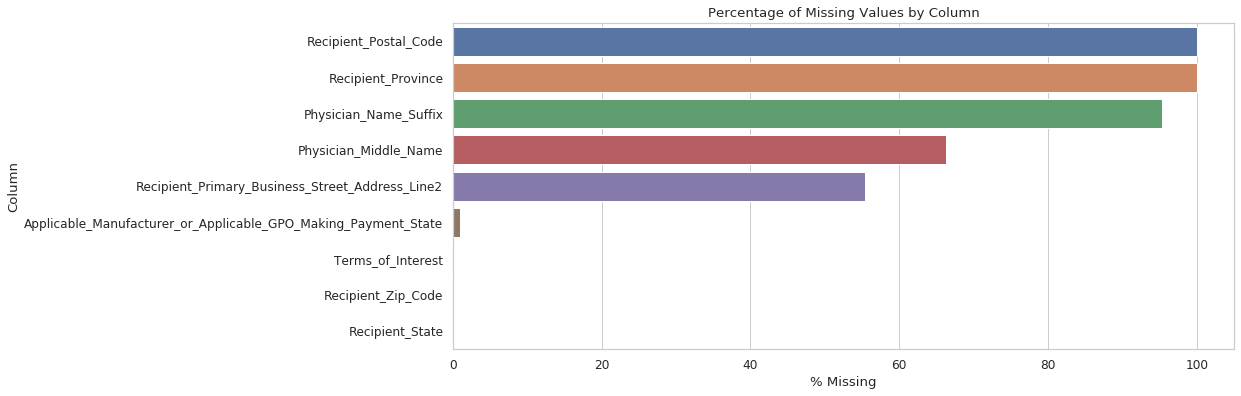

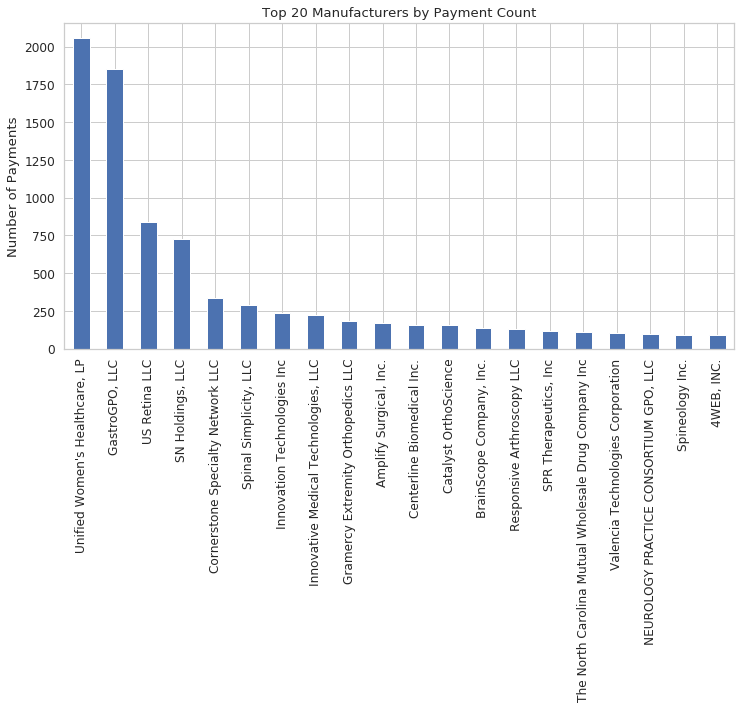

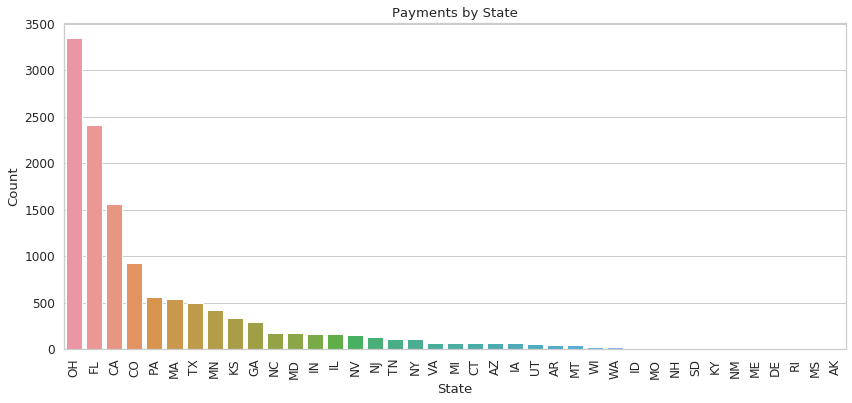

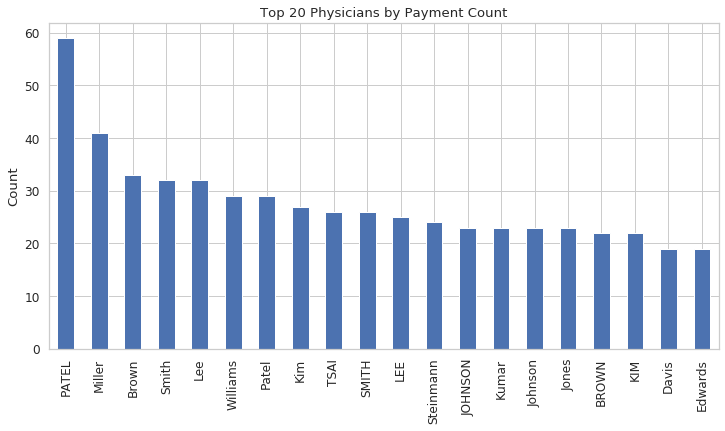

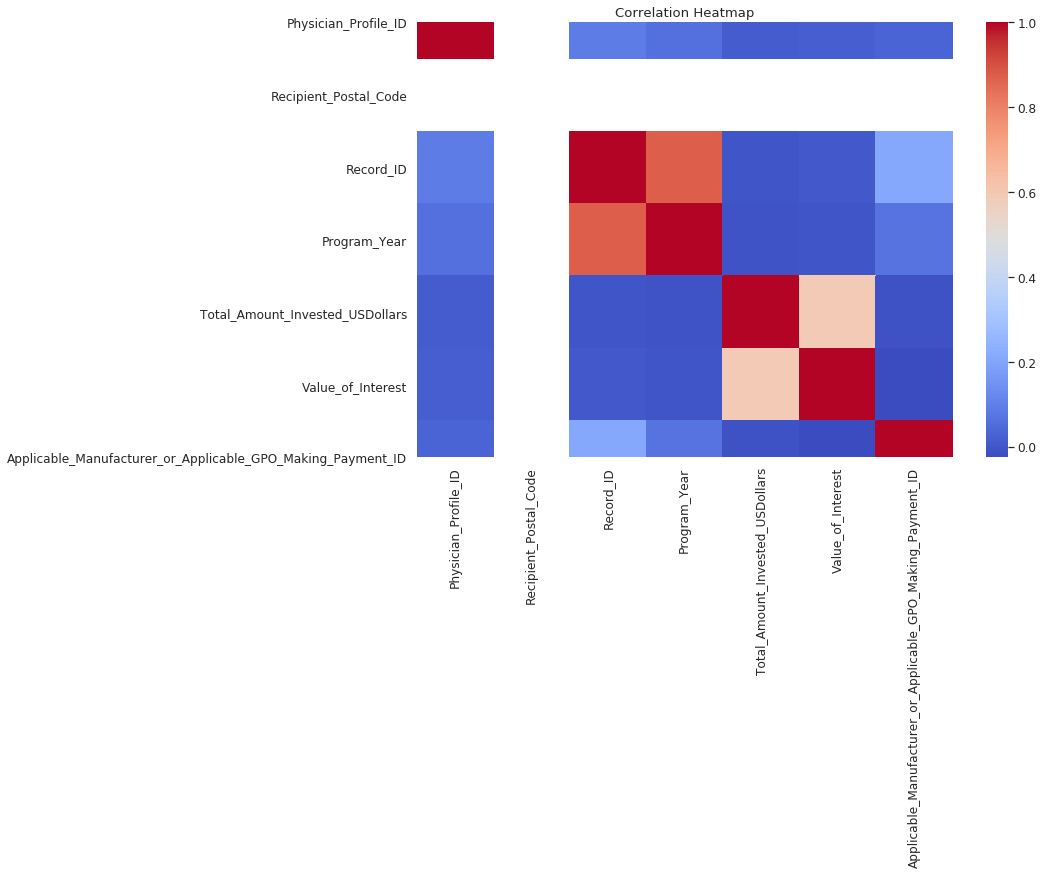

In [26]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles
sns.set(style="whitegrid", font_scale=1.1)

# # ============================
# # 2. Load Your Datasets
# # ============================
# df = pd.read_csv("/dsa/groups/casestudycf25/team02/OWNRSHP_PGYR2021_2023.csv")
# df2 = pd.read_csv("/dsa/groups/casestudycf25/team02/LEIE_OIG_Exclusion_List.csv", dtype=str)

# # ============================
# # 3. Structure
# # ============================
# print("Shape:", df.shape)
# print(df.info())

# # ============================
# # 4. Missing Data Visualization (No missingno)
# # ============================

# --- Bar chart: % missing per column ---
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=missing_percent.values, y=missing_percent.index)
plt.title("Percentage of Missing Values by Column")
plt.xlabel("% Missing")
plt.ylabel("Column")
plt.show()


# ============================
# 7. Top 20 Manufacturers
# ============================
plt.figure(figsize=(12,6))
df["Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name"] \
    .value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Manufacturers by Payment Count")
plt.ylabel("Number of Payments")
plt.show()

# ============================
# 8. Payment Distribution by State
# ============================
plt.figure(figsize=(14,6))
state_counts = df["Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State"].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.xticks(rotation=90)
plt.title("Payments by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

# ============================
# 9. Payments by Physician
# ============================
plt.figure(figsize=(12,6))
df["Physician_Last_Name"].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Physicians by Payment Count")
plt.ylabel("Count")
plt.show()

# ============================
# 10. Correlation Heatmap (numeric)
# ============================
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Ownership Records by Exclusion Status

- Flag providers in the dataset as `Excluded` if they appear in OIG Exclusion List.
- Bar chart shows counts of excluded vs. not-excluded ownership records.

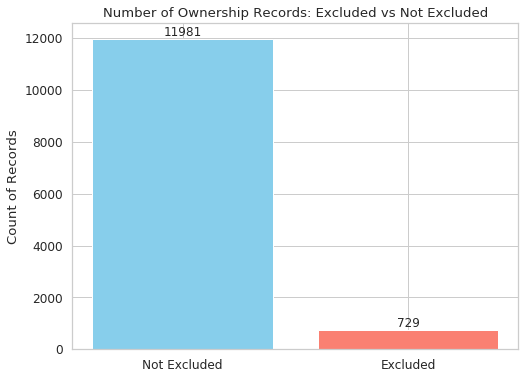

In [27]:
# Excluded VS Not-Excluded
import matplotlib.pyplot as plt

# Create a label column
df["Excluded"] = df["Physician_NPI"].isin(exclusions["Physician_NPI"])

# Count excluded vs not
counts = df["Excluded"].value_counts()

plt.figure(figsize=(8,6))
bars = plt.bar(["Not Excluded", "Excluded"], counts.values, color=['skyblue', 'salmon'])

# Add counts on top of the bars
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), 
             ha='center', va='bottom', fontsize=12)

plt.title("Number of Ownership Records: Excluded vs Not Excluded")
plt.ylabel("Count of Records")
plt.show()


### Payment Value Distribution

- Boxplot compares `Value_of_Interest` for excluded vs not-excluded providers.
- Visualizes whether excluded providers tend to have higher or lower payments.


<Figure size 720x432 with 0 Axes>

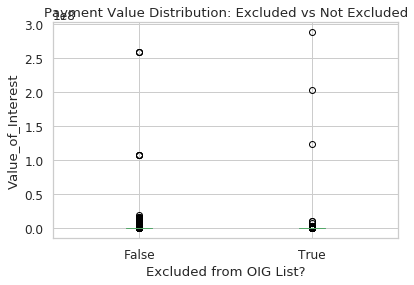

In [28]:
#Payment Value Comparison (BOXPLOT)
plt.figure(figsize=(10,6))

df.boxplot(
    column="Value_of_Interest",
    by="Excluded",
    patch_artist=True
)

plt.title("Payment Value Distribution: Excluded vs Not Excluded")
plt.suptitle("")
plt.xlabel("Excluded from OIG List?")
plt.ylabel("Value_of_Interest")
plt.show()

### Geographic Analysis of Exclusions

1. **Top States for Excluded Payments:** Bar chart shows states with the highest number of excluded provider payments.
2. **Exclusion Rate by State:** Bar chart shows the percentage of providers excluded per state (relative to total providers in that state).


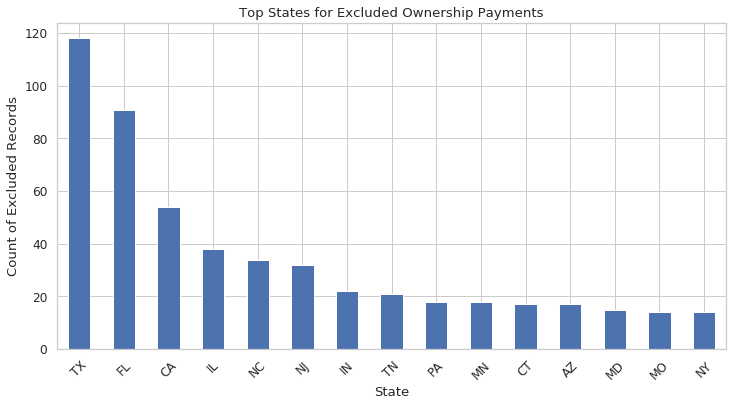

In [29]:
#State-Level Overlap (Bar Chart)
# Get physician states for excluded providers
excluded_states = df[df["Excluded"]]["Recipient_State"].value_counts().head(15)

plt.figure(figsize=(12,6))
excluded_states.plot(kind="bar")
plt.title("Top States for Excluded Ownership Payments")
plt.xlabel("State")
plt.ylabel("Count of Excluded Records")
plt.xticks(rotation=45)
plt.show()


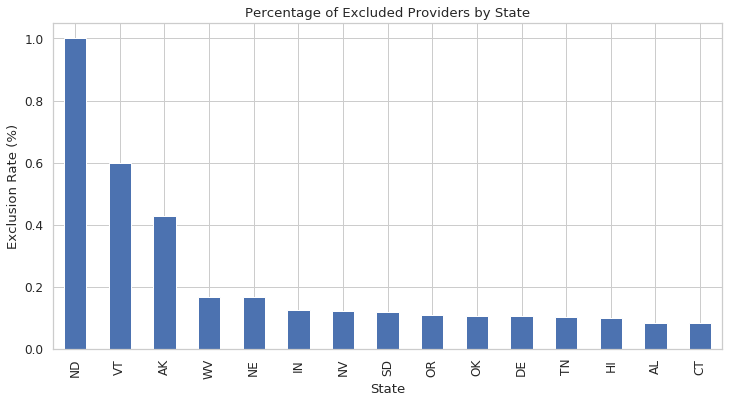

In [30]:
#Highlight Exclusion Ratio by State
# Group by state
state_summary = df.groupby("Recipient_State")["Excluded"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
state_summary.plot(kind="bar")
plt.title("Percentage of Excluded Providers by State")
plt.ylabel("Exclusion Rate (%)")
plt.xlabel("State")
plt.show()

### Summary and Insights

This analysis of physician ownership payments from 2021–2023, combined with the OIG Exclusion List, provides several key insights:

1. **Data Quality and Cleaning**  
   - Several columns had missing values, most notably `Recipient_Postal_Code`, `Recipient_Province`, and `Physician_Name_Suffix`.  
   - Standardizing NPIs and physician names allowed accurate matching with the exclusion list.

2. **Exclusions Overview**  
   - A total of 278 physicians/entities were identified as matching the OIG Exclusion List.  
   - 4,491 unique physicians/entities were not excluded, representing the majority of the dataset.

3. **Payment Distribution and Patterns**  
   - Excluded providers tend to have varying payment values, with some significantly higher than non-excluded providers.  
   - Top manufacturers and states were visualized to identify patterns in ownership payments.

4. **State-Level Insights**  
   - Certain states had higher proportions of excluded providers.  
   - This highlights potential areas of focus for compliance monitoring or further investigation.

5. **Actionable Outcomes**  
   - The cleaned, exclusion-filtered dataset provides a reliable foundation for further analysis or modeling.  
   - Organizations can use these insights to enhance compliance, auditing, and risk management processes.

Overall, this exploratory analysis highlights the importance of **data cleaning, exclusion checks, and state-level monitoring** in understanding physician ownership payments and ensuring regulatory compliance.